In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

### Data Info

In [3]:
df.shape

(400, 5)

In [4]:
df.head(10)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


In [5]:
df = df.drop("User ID", axis = 1)

In [6]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [7]:
df.duplicated().sum()

np.int64(20)

In [8]:
df.isnull().sum()

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           400 non-null    str  
 1   Age              400 non-null    int64
 2   EstimatedSalary  400 non-null    int64
 3   Purchased        400 non-null    int64
dtypes: int64(3), str(1)
memory usage: 14.6 KB


### EDA

<Axes: xlabel='Purchased', ylabel='count'>

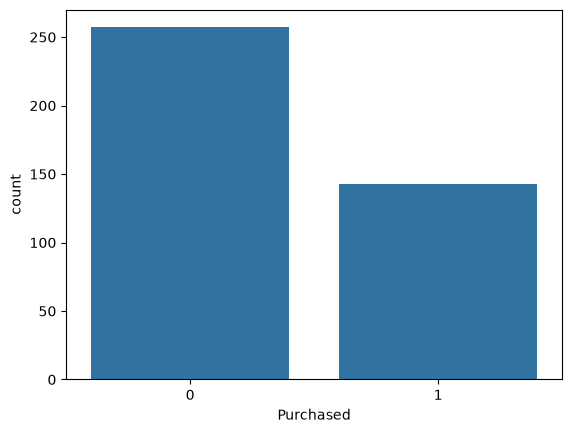

In [10]:
sns.countplot(x=df["Purchased"])

<Axes: xlabel='Age', ylabel='Count'>

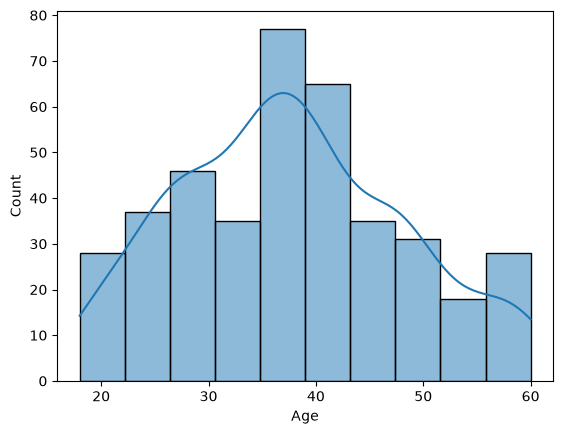

In [11]:
sns.histplot(df["Age"],kde=True)

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

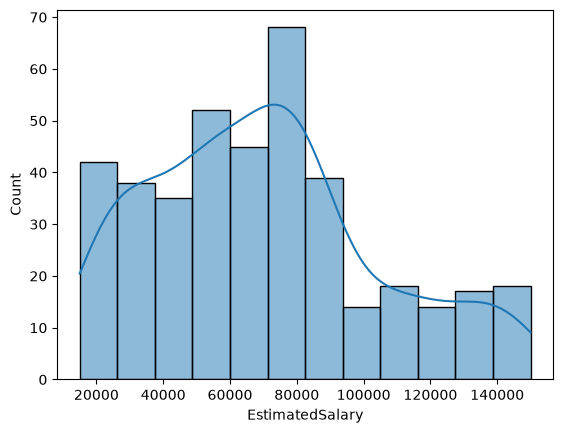

In [12]:
sns.histplot(df["EstimatedSalary"],kde=True)

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

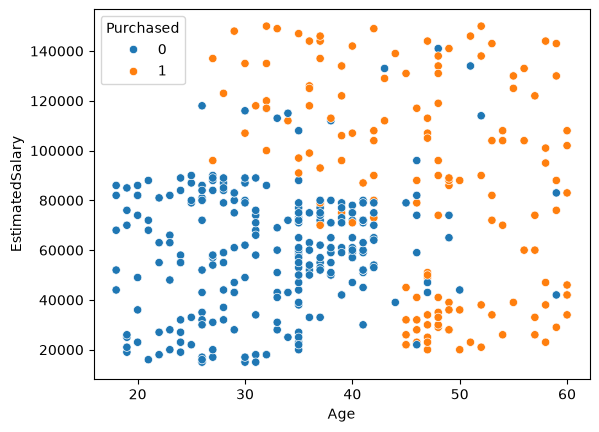

In [13]:
sns.scatterplot(data=df,x="Age",y="EstimatedSalary",hue="Purchased")

<Axes: xlabel='Purchased', ylabel='Age'>

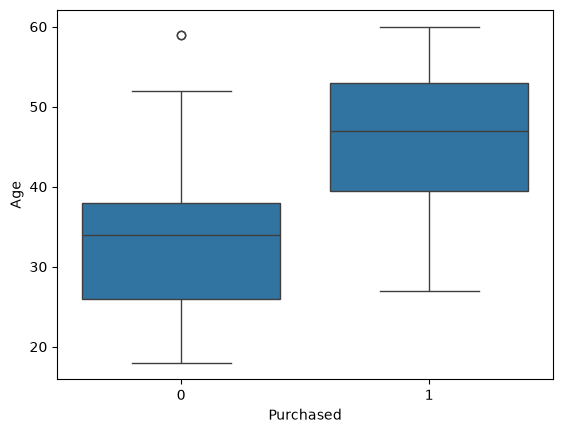

In [14]:
sns.boxplot(x="Purchased", y="Age", data=df)

<Axes: xlabel='Purchased', ylabel='EstimatedSalary'>

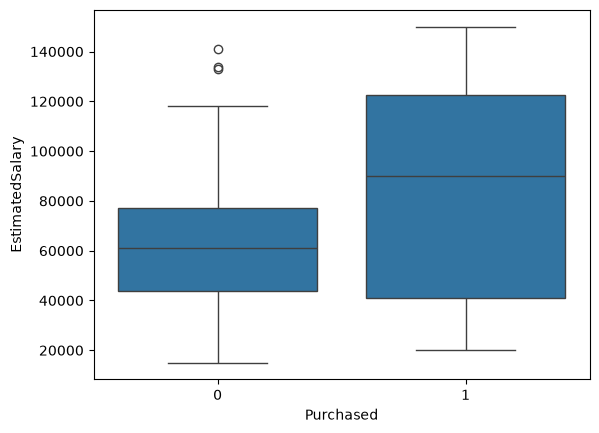

In [15]:
sns.boxplot(x="Purchased", y="EstimatedSalary", data=df)

<Axes: >

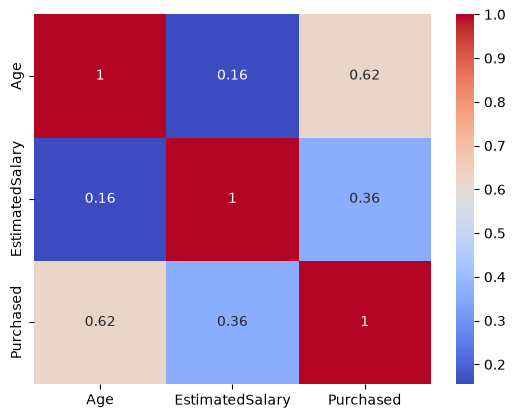

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

### Data Preprocessing

In [17]:
X = df.drop("Purchased",axis=1)
y = df["Purchased"]

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), ["Age", "EstimatedSalary"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["Gender"])
])

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(kernel="rbf"))
])

In [20]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_train_transformed.shape

(320, 4)

In [21]:
model = model_pipeline.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.925
Precision: 0.8666666666666667
Recall: 0.9285714285714286
F1 Score: 0.896551724137931


In [23]:
import joblib
joblib.dump(model_pipeline, "model.pkl")

['model.pkl']